In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



#Load Data

In [4]:
df = pd.read_csv("Supplychain_rawData.csv")
df.head()

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,SO - 000101,In-Store,WARE-UHY1004,31/12/17,31/5/18,14/6/18,19/6/18,USD,6,15,259,12,5,0.08,"$1,001.18","$1,963.10"
1,SO - 000102,Online,WARE-NMK1003,31/12/17,31/5/18,22/6/18,2/7/2018,USD,14,20,196,27,3,0.08,"$3,348.66","$3,939.60"
2,SO - 000103,Distributor,WARE-UHY1004,31/12/17,31/5/18,21/6/18,1/7/2018,USD,21,16,213,16,1,0.05,$781.22,"$1,775.50"
3,SO - 000104,Wholesale,WARE-NMK1003,31/12/17,31/5/18,2/6/2018,7/6/2018,USD,28,48,107,23,8,0.08,"$1,464.69","$2,324.90"
4,SO - 000105,Distributor,WARE-NMK1003,10/4/2018,31/5/18,16/6/18,26/6/18,USD,22,49,111,26,8,0.10,"$1,476.14","$1,822.40"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderNumber       7991 non-null   object 
 1   Sales Channel     7991 non-null   object 
 2   WarehouseCode     7991 non-null   object 
 3   ProcuredDate      7991 non-null   object 
 4   OrderDate         7991 non-null   object 
 5   ShipDate          7991 non-null   object 
 6   DeliveryDate      7991 non-null   object 
 7   CurrencyCode      7991 non-null   object 
 8   _SalesTeamID      7991 non-null   int64  
 9   _CustomerID       7991 non-null   int64  
 10  _StoreID          7991 non-null   int64  
 11  _ProductID        7991 non-null   int64  
 12  Order Quantity    7991 non-null   int64  
 13  Discount Applied  7991 non-null   float64
 14  Unit Cost         7991 non-null   object 
 15  Unit Price        7991 non-null   object 
dtypes: float64(1), int64(5), object(10)
memory

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
_SalesTeamID,7991.0,14.384307,7.986086,1.00,8.00,14.00,21.00,28.0
_CustomerID,7991.0,25.457014,14.414883,1.00,13.00,25.00,38.00,50.0
_StoreID,7991.0,183.850081,105.903946,1.00,91.00,183.00,276.00,367.0
_ProductID,7991.0,23.771743,13.526545,1.00,12.00,24.00,36.00,47.0
Order Quantity,7991.0,4.525341,2.312631,1.00,3.00,5.00,7.00,8.0
Discount Applied,7991.0,0.115649,0.085018,0.05,0.05,0.08,0.15,0.4


In [7]:
# Handle missing values
df.dropna(inplace=True)


In [8]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [9]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")


In [10]:
# Clean currency columns
df['Unit_Price'] = df['Unit_Price'].replace(r'[\$,]', '', regex=True).astype(float)
df['Unit_Cost'] = df['Unit_Cost'].replace(r'[\$,]', '', regex=True).astype(float)

In [11]:
# Convert dates
df['OrderDate'] = pd.to_datetime(df['OrderDate'], dayfirst=True)
df['ShipDate'] = pd.to_datetime(df['ShipDate'], dayfirst=True)
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'], dayfirst=True)
df['ProcuredDate'] = pd.to_datetime(df['ProcuredDate'], dayfirst=True)

/tmp/ipykernel_1975/2316236487.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'], dayfirst=True)
/tmp/ipykernel_1975/2316236487.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ShipDate'] = pd.to_datetime(df['ShipDate'], dayfirst=True)
/tmp/ipykernel_1975/2316236487.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'], dayfirst=True)
/tmp/ipykernel_1975/2316236487.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back 

In [12]:
# Feature engineering
df['delivery_days'] = (df['DeliveryDate'] - df['ShipDate']).dt.days
df['revenue'] = df['Order_Quantity'] * df['Unit_Price']
df['total_cost'] = df['Order_Quantity'] * df['Unit_Cost']
df['profit'] = df['revenue'] - df['total_cost']
df['order_to_ship_days'] = (df['ShipDate'] - df['OrderDate']).dt.days
df['procure_to_order_days'] = (df['OrderDate'] - df['ProcuredDate']).dt.days

In [13]:
#Bussiness Insights

# 1. Top revenue channel
top_channel = df.groupby('Sales_Channel')['revenue'].sum().idxmax()
print(f"Top Revenue Channel: {top_channel}")

# 2. Fastest warehouse
fastest_wh = df.groupby('WarehouseCode')['delivery_days'].mean().idxmin()
print(f"Fastest Warehouse: {fastest_wh}")

# 3. Slowest warehouse
slowest_wh = df.groupby('WarehouseCode')['delivery_days'].mean().idxmax()
print(f"Slowest Warehouse: {slowest_wh}")

# 4. High discount impact
high_discount = df[df['Discount_Applied'] > 0.2]['revenue'].mean()
low_discount = df[df['Discount_Applied'] <= 0.2]['revenue'].mean()

print(f"Avg Revenue with High Discount: {round(high_discount,2)}")
print(f"Avg Revenue with Low Discount: {round(low_discount,2)}")

# 5. Delivery risk insight
delayed_orders = df[df['delivery_days'] > df['delivery_days'].mean()].shape[0]
print(f"Orders with above-average delivery time: {delayed_orders}")

Top Revenue Channel: In-Store
Fastest Warehouse: WARE-MKL1006
Slowest Warehouse: WARE-XYS1001
Avg Revenue with High Discount: 11057.85
Avg Revenue with Low Discount: 10283.61
Orders with above-average delivery time: 3953


In [14]:
# KPI Analysis
print("\n===== KPI =====")
print(df[['revenue','profit','delivery_days']].agg(['sum','mean','min','max']))

print("\nSales by Channel:")
print(df.groupby('Sales_Channel')['revenue'].sum())

print("\nDelivery by Warehouse:")
print(df.groupby('WarehouseCode')['delivery_days'].mean())


===== KPI =====
           revenue        profit  delivery_days
sum   8.269273e+07  3.087466e+07   43982.000000
mean  1.034823e+04  3.863679e+03       5.503942
min   1.675000e+02  2.512000e+01       1.000000
max   5.231360e+04  3.090576e+04      10.000000

Sales by Channel:
Sales_Channel
Distributor    14809907.8
In-Store       34040113.8
Online         24629756.1
Wholesale       9212948.9
Name: revenue, dtype: float64

Delivery by Warehouse:
WarehouseCode
WARE-MKL1006    5.348891
WARE-NBV1002    5.377713
WARE-NMK1003    5.509381
WARE-PUJ1005    5.584425
WARE-UHY1004    5.496443
WARE-XYS1001    5.585106
Name: delivery_days, dtype: float64


#Visualization

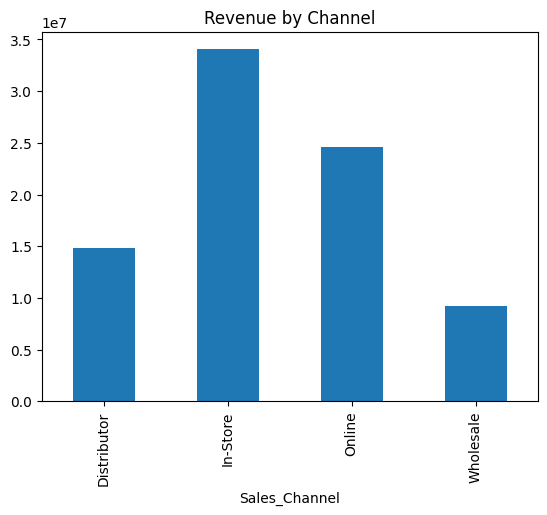

In [15]:
# Revenue by channel
df.groupby('Sales_Channel')['revenue'].sum().plot(kind='bar', title="Revenue by Channel")
plt.show()

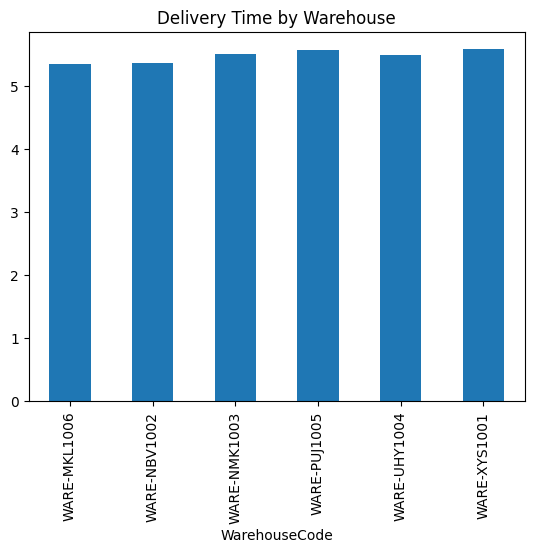

In [16]:
# Delivery by warehouse
df.groupby('WarehouseCode')['delivery_days'].mean().plot(kind='bar', title="Delivery Time by Warehouse")
plt.show()

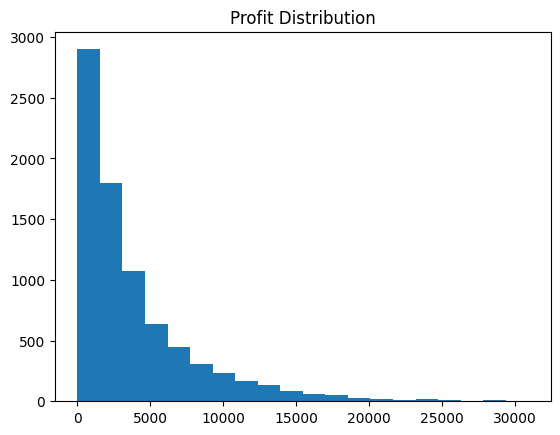

In [17]:
# Profit distribution
plt.hist(df['profit'], bins=20)
plt.title("Profit Distribution")
plt.show()


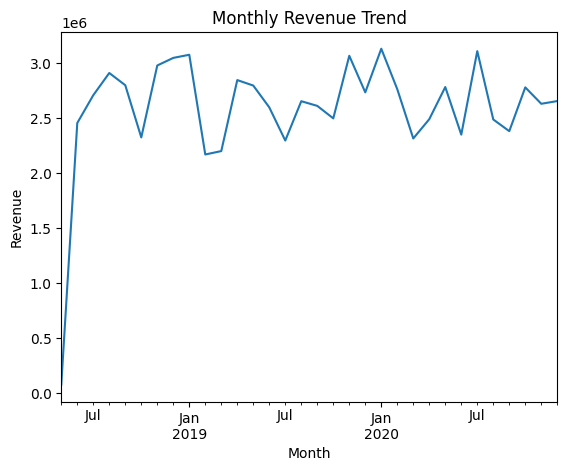

In [18]:
# Monthly trend
df.groupby(df['OrderDate'].dt.to_period('M'))['revenue'].sum().plot(kind='line', title="Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

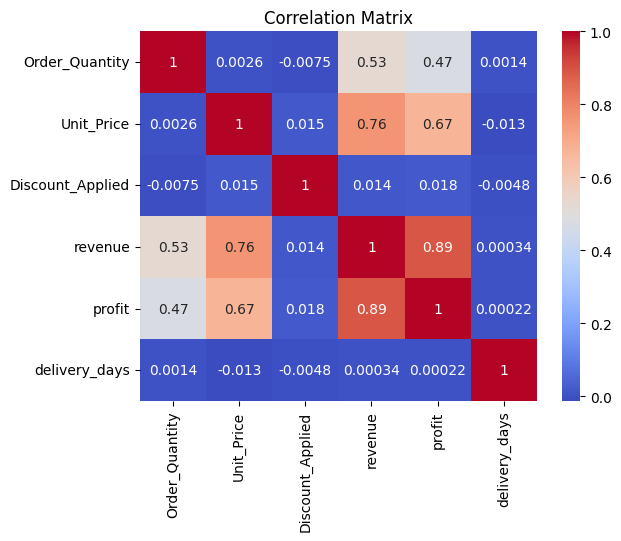

In [19]:
corr = df[['Order_Quantity','Unit_Price','Discount_Applied','revenue','profit','delivery_days']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
# Executive summary

print(f"Total revenue: {df['revenue'].sum():,.0f}")
print(f"Total profit: {df['profit'].sum():,.0f}")
print(f"Average delivery days: {df['delivery_days'].mean():.2f}")
print("Top performing channel:", df.groupby('Sales_Channel')['revenue'].sum().idxmax())
print("Fastest warehouse:", df.groupby('WarehouseCode')['delivery_days'].mean().idxmin())

Total revenue: 82,692,727
Total profit: 30,874,658
Average delivery days: 5.50
Top performing channel: In-Store
Fastest warehouse: WARE-MKL1006


In [21]:
# Export cleaned data for Excel / Power BI
df.to_csv("Cleaned_Supplychain_Data.csv", index=False)